<a href="https://www.kaggle.com/code/kedhareswernaidu/setiment-analysis-using-distilbert?scriptVersionId=243061202" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

## Traditional vs Transformer Sentiment Analysis on IMDB

#### 🔍 Goal
* Train and evaluate traditional NLP models on IMDB reviews and compare their performance to a transformer model (distilbert-base-uncased-finetuned-sst-2-english) from Hugging Face.


In [1]:
# Imports
from datasets import load_dataset
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import make_pipeline
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, accuracy_score
from transformers import pipeline
import matplotlib.pyplot as plt
import seaborn as sns

2025-06-01 12:38:39.971164: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1748781520.196609      19 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1748781520.266342      19 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


### Step 1: Load and Explore the Dataset

In [2]:
# 1. Load IMDB dataset
ds = load_dataset("stanfordnlp/imdb")
train_df = pd.DataFrame(ds["train"])
test_df = pd.DataFrame(ds["test"])

README.md:   0%|          | 0.00/7.81k [00:00<?, ?B/s]

train-00000-of-00001.parquet:   0%|          | 0.00/21.0M [00:00<?, ?B/s]

test-00000-of-00001.parquet:   0%|          | 0.00/20.5M [00:00<?, ?B/s]

unsupervised-00000-of-00001.parquet:   0%|          | 0.00/42.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

### Step 2: Prepare Data
* Convert the Hugging Face dataset to Pandas for sklearn compatibility:

In [3]:
label_map = {0: "negative", 1: "positive"}
train_df["label"] = train_df["label"].map(label_map)
test_df["label"] = test_df["label"].map(label_map)

### Step 3: Train Traditional NLP Models
* Using TfidfVectorizer + classifier (Naive Bayes, Logistic Regression, etc.):

In [4]:
# 2. Train Traditional NLP Model
model = make_pipeline(TfidfVectorizer(max_features=10000), MultinomialNB())
model.fit(train_df["text"], train_df["label"])

Pipeline(steps=[('tfidfvectorizer', TfidfVectorizer(max_features=10000)),
                ('multinomialnb', MultinomialNB())])

### Step 4: Use Transformer for Benchmark

In [5]:
# Load transformer pipeline
pipe = pipeline("text-classification", model="distilbert/distilbert-base-uncased-finetuned-sst-2-english")

config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

Device set to use cuda:0


### Step 5: Evaluation

In [6]:
subset = test_df.sample(500, random_state=42).reset_index(drop=True)
transformer_preds = pipe(subset["text"].tolist(), truncation=True, batch_size=8)
y_pred_transformer = [p["label"].lower() for p in transformer_preds]

print("\nTraditional Model Report:")
print(classification_report(test_df["label"], model.predict(test_df["text"])))

print("\nTransformer Model Report:")
print(classification_report(subset["label"], y_pred_transformer))


Traditional Model Report:
              precision    recall  f1-score   support

    negative       0.81      0.87      0.84     12500
    positive       0.86      0.80      0.83     12500

    accuracy                           0.84     25000
   macro avg       0.84      0.84      0.84     25000
weighted avg       0.84      0.84      0.84     25000


Transformer Model Report:
              precision    recall  f1-score   support

    negative       0.89      0.91      0.90       266
    positive       0.89      0.87      0.88       234

    accuracy                           0.89       500
   macro avg       0.89      0.89      0.89       500
weighted avg       0.89      0.89      0.89       500



In [7]:
def plot_confusion_matrices():
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    ConfusionMatrixDisplay.from_predictions(
        test_df["label"], model.predict(test_df["text"]), ax=axes[0], cmap='Blues'
    )
    axes[0].set_title("Naive Bayes Confusion Matrix")

    ConfusionMatrixDisplay.from_predictions(
        subset["label"], y_pred_transformer, ax=axes[1], cmap='Greens'
    )
    axes[1].set_title("DistilBERT Confusion Matrix")

    plt.tight_layout()
    plt.show()

In [8]:
def plot_accuracy_comparison():
    accuracy_traditional = accuracy_score(test_df["label"], model.predict(test_df["text"]))
    accuracy_transformer = accuracy_score(subset["label"], y_pred_transformer)

    plt.figure(figsize=(6,4))
    sns.barplot(x=["Naive Bayes", "DistilBERT"], y=[accuracy_traditional, accuracy_transformer], palette="pastel")
    plt.ylabel("Accuracy")
    plt.ylim(0.7, 1)
    plt.title("Model Accuracy Comparison")
    for i, v in enumerate([accuracy_traditional, accuracy_transformer]):
        plt.text(i, v + 0.01, f"{v:.3f}", ha='center')
    plt.show()

In [9]:
def test_custom_texts(texts):
    """
    texts: list of strings to classify
    """
    print(f"Testing {len(texts)} texts...\n")

    # Traditional model predictions
    traditional_preds = model.predict(texts)

    # Transformer model predictions with truncation and batching
    transformer_results = pipe(texts, truncation=True, batch_size=8)
    transformer_preds = [res["label"].lower() for res in transformer_results]

    # Show side-by-side results in a DataFrame
    results_df = pd.DataFrame({
        "Text": texts,
        "Traditional Prediction": traditional_preds,
        "Transformer Prediction": transformer_preds
    })

    print(results_df)

    # Visualize prediction counts
    fig, ax = plt.subplots(1, 2, figsize=(12, 4))

    sns.countplot(x="Traditional Prediction", data=results_df, ax=ax[0], palette="Blues")
    ax[0].set_title("Traditional Model Predictions")

    sns.countplot(x="Transformer Prediction", data=results_df, ax=ax[1], palette="Greens")
    ax[1].set_title("Transformer Model Predictions")

    plt.tight_layout()
    plt.show()

Testing 4 texts...

                                             Text Traditional Prediction  \
0  I really enjoyed this movie, it was fantastic!               positive   
1               The film was boring and too long.               negative   
2                  Mediocre acting but good plot.               negative   
3             Absolutely wonderful! A must-watch.               positive   

  Transformer Prediction  
0               positive  
1               negative  
2               positive  
3               positive  


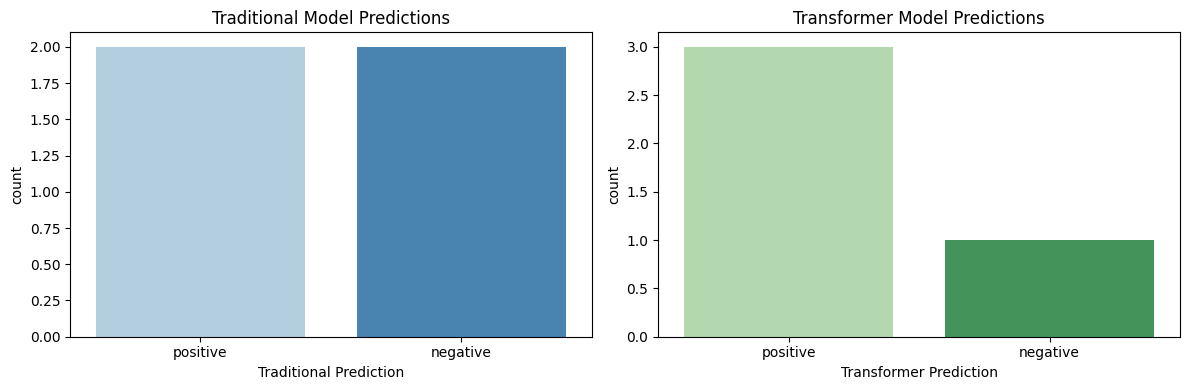

In [10]:
# Example usage
custom_texts = [
    "I really enjoyed this movie, it was fantastic!",
    "The film was boring and too long.",
    "Mediocre acting but good plot.",
    "Absolutely wonderful! A must-watch."
]

test_custom_texts(custom_texts)

### Playground

In [11]:
import ipywidgets as widgets
from IPython.display import display, clear_output
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Global DataFrame to store all inputs, preds, and feedback
if "history_df" not in globals():
    history_df = pd.DataFrame(columns=["Text", "Traditional Prediction", "Transformer Prediction", "User Feedback"])

# Explanation helpers (same as before)
def explain_traditional(text):
    vect = model.named_steps['tfidfvectorizer']
    clf = model.named_steps['multinomialnb']
    X = vect.transform([text])
    feature_names = np.array(vect.get_feature_names_out())
    label_index = clf.classes_.tolist().index(model.predict([text])[0])
    log_probs = clf.feature_log_prob_[label_index]
    top_feats_idx = np.argsort(log_probs)[::-1][:10]
    top_feats = feature_names[top_feats_idx]
    top_probs = log_probs[top_feats_idx]
    return list(zip(top_feats, top_probs))

positive_words = {"love","good","great","fantastic","excellent","wonderful","amazing","best","perfect","enjoyed","liked","awesome"}
negative_words = {"bad","terrible","boring","worst","awful","hate","disappointing","poor","dull","annoying","waste","mediocre"}
from transformers import AutoTokenizer
tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")

def explain_transformer(text):
    tokens = tokenizer.tokenize(text.lower())
    pos_hits = [t for t in tokens if t in positive_words]
    neg_hits = [t for t in tokens if t in negative_words]
    return {"positive_tokens": pos_hits, "negative_tokens": neg_hits}

# UI Elements
text_input = widgets.Textarea(
    value='Type or paste one or more texts here, each on a new line.',
    placeholder='Enter text...',
    description='Input Text:',
    layout=widgets.Layout(width='100%', height='150px')
)
analyze_button = widgets.Button(description="Analyze Sentiment", button_style='success')
output = widgets.Output()

# For storing feedback widgets so we can clear or update
feedback_widgets = []

def update_visualizations():
    global history_df
    if history_df.empty:
        print("No feedback data yet.")
        return

    fig, ax = plt.subplots(1, 3, figsize=(18, 4))

    # Prediction counts
    sns.countplot(x="Traditional Prediction", data=history_df, ax=ax[0], palette="Blues")
    ax[0].set_title("Traditional Model Predictions")

    sns.countplot(x="Transformer Prediction", data=history_df, ax=ax[1], palette="Greens")
    ax[1].set_title("Transformer Model Predictions")

    # Feedback summary: how often each model was voted correct or neither
    fb_counts = history_df["User Feedback"].value_counts().reindex(
        ["Traditional Correct", "Transformer Correct", "Neither"], fill_value=0
    )
    ax[2].bar(fb_counts.index, fb_counts.values, color=["blue", "green", "grey"])
    ax[2].set_title("User Feedback Votes")
    ax[2].set_ylabel("Count")

    plt.tight_layout()
    plt.show()

def on_feedback_change(change, idx):
    global history_df
    if change['type'] == 'change' and change['name'] == 'value':
        val = change['new']
        if val != "":  # Only accept non-empty feedback
            history_df.at[idx, "User Feedback"] = val
            # Clear the selection to allow new inputs without confusion
            feedback_widgets[idx].value = None
            with output:
                clear_output(wait=True)
                print(f"Feedback recorded for input #{idx+1}.")
                update_visualizations()

def on_analyze_clicked(b):
    global history_df, feedback_widgets
    with output:
        clear_output()
        texts = [line.strip() for line in text_input.value.strip().split('\n') if line.strip()]
        if not texts:
            print("Please enter at least one non-empty text line.")
            return

        trad_preds = model.predict(texts)
        trans_results = pipe(texts, truncation=True, batch_size=8)
        trans_preds = [res['label'].lower() for res in trans_results]

        # Append new inputs to history_df
        new_data = pd.DataFrame({
            "Text": texts,
            "Traditional Prediction": trad_preds,
            "Transformer Prediction": trans_preds,
            "User Feedback": [None]*len(texts)
        })
        history_df = pd.concat([history_df, new_data], ignore_index=True)

        # Show full history
        display(history_df)

        # Show explanations & feedback widgets for *new* inputs only
        feedback_widgets = []
        for i in range(len(history_df) - len(texts), len(history_df)):
            row = history_df.iloc[i]
            print(f"\n--- Text #{i+1} ---")
            print(f"Input: {row['Text']}")
            print(f"Traditional Prediction: {row['Traditional Prediction']}")
            print("Top weighted features contributing to prediction:")
            feats = explain_traditional(row['Text'])
            for f, p in feats:
                print(f"  - {f}: {p:.3f}")
            print(f"\nTransformer Prediction: {row['Transformer Prediction']}")
            exp = explain_transformer(row['Text'])
            print(f"Tokens suggesting positive sentiment: {', '.join(exp['positive_tokens']) if exp['positive_tokens'] else 'None'}")
            print(f"Tokens suggesting negative sentiment: {', '.join(exp['negative_tokens']) if exp['negative_tokens'] else 'None'}")

            # Feedback widget for this input
            fb = widgets.RadioButtons(
                options=["", "Traditional Correct", "Transformer Correct", "Neither"],
                description='Feedback:',
                disabled=False
            )
            fb.observe(lambda change, idx=i: on_feedback_change(change, idx), names='value')
            display(fb)
            feedback_widgets.append(fb)

        # Show visualizations
        update_visualizations()

analyze_button.on_click(on_analyze_clicked)

display(text_input, analyze_button, output)

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Textarea(value='Type or paste one or more texts here, each on a new line.', description='Input Text:', layout=…

Button(button_style='success', description='Analyze Sentiment', style=ButtonStyle())

Output()